In [1]:
# ==============================================================================
# PROJECT: INSURANCE COGNITIVE RISK ENGINE
# AUTHOR: Senior Data Analyst Candidate
# OBJECTIVE: Dual-Module Analytics for Corporate Health & Reinsurance Optimization
# ==============================================================================

# --- 1. LIBRARY IMPORTS ---
import pandas as pd             # For data manipulation (Excel-like tables)
import numpy as np              # For heavy math and random number generation
import matplotlib.pyplot as plt # For basic plotting
import seaborn as sns           # For professional, statistical visualizations
from sklearn.preprocessing import StandardScaler # To scale data for AI
from sklearn.cluster import KMeans               # The AI algorithm for grouping
from scipy import stats                          # For Actuarial distribution fitting

# Set random seed for reproducibility (so your results match mine exactly)
np.random.seed(42)

print(">>> SYSTEM START: Initializing Risk Analytics Modules...")

>>> SYSTEM START: Initializing Risk Analytics Modules...


In [3]:
# ==============================================================================
# MODULE A: CORPORATE HEALTH RISK STRATIFICATION
# GOAL: Identify High-Risk Employee segments to lower premiums for HR Clients.
# ==============================================================================
print("\n[MODULE A] Launching Corporate Health Engine...")

# 1. LOAD DATA
try:
    health_df = pd.read_csv('data/insurance.csv')
    print(f"   - Data Loaded: {health_df.shape[0]} Lives Covered.")
except FileNotFoundError:
    print("   ! ERROR: 'data/insurance.csv' not found. Please check folder structure.")

# 2. DATA ENGINEERING (LOCALIZATION)
# Convert USD to Local Currency (e.g., INR) using PPP Factor ~30
health_df['charges_local'] = (health_df['charges'] * 30).round(2)

# Map Generic Regions to Strategic Zones
health_df['region_tier'] = health_df['region'].map({
    'southwest': 'Zone 1 (Metro/High Cost)',
    'southeast': 'Zone 2 (Tech Hubs)',
    'northwest': 'Zone 3 (Industrial)',
    'northeast': 'Zone 4 (Tier 2/3 Cities)'
})

# 3. SMOKER ENCODING
health_df['smoker_code'] = health_df['smoker'].map({'yes': 1, 'no': 0})

# 4. RISK ENGINE (CLUSTERING)
# We include 'charges_local' to ensure the AI groups people by COST.
features = ['age', 'bmi', 'smoker_code', 'charges_local']
X = health_df[features].copy()

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# AI Execution: Find 3 distinct risk clusters
kmeans = KMeans(n_clusters=3, random_state=42)
health_df['risk_cluster'] = kmeans.fit_predict(X_scaled)

# 5. BUSINESS LOGIC MAPPING
# Map clusters to "Red/Yellow/Green" based on average cost
cluster_costs = health_df.groupby('risk_cluster')['charges_local'].mean().sort_values(ascending=False)

risk_map = {
    cluster_costs.index[0]: 'Zone Red (Critical)',   # Highest Cost
    cluster_costs.index[1]: 'Zone Yellow (At-Risk)', # Medium Cost
    cluster_costs.index[2]: 'Zone Green (Healthy)'   # Lowest Cost
}
health_df['Risk_Category'] = health_df['risk_cluster'].map(risk_map)

# Show the profile of each Zone
summary = health_df.groupby('Risk_Category')[['age', 'bmi', 'charges_local', 'smoker_code']].mean().round(2)
count = health_df['Risk_Category'].value_counts()
summary['count'] = count

# Save processed data
health_df.to_csv('data/Health_Risk_Engine_Output.csv', index=False)
print("   - Risk Stratification Complete. Data Saved.")
display(summary)


[MODULE A] Launching Corporate Health Engine...
   - Data Loaded: 1338 Lives Covered.
   - Risk Stratification Complete. Data Saved.


,age,bmi,charges_local,smoker_code,count
Risk_Category,,,,,
Zone Green (Healthy),27.42,29.48,151568.12,0.0,541
Zone Red (Critical),38.51,30.71,961506.95,1.0,274
Zone Yellow (At-Risk),51.76,31.87,357979.90,0.0,523



[MODULE B] Launching Reinsurance Stochastic Lab...
   - Reinsurance Data Loaded: 26639 Claims.
   - Monte Carlo Simulation Complete.


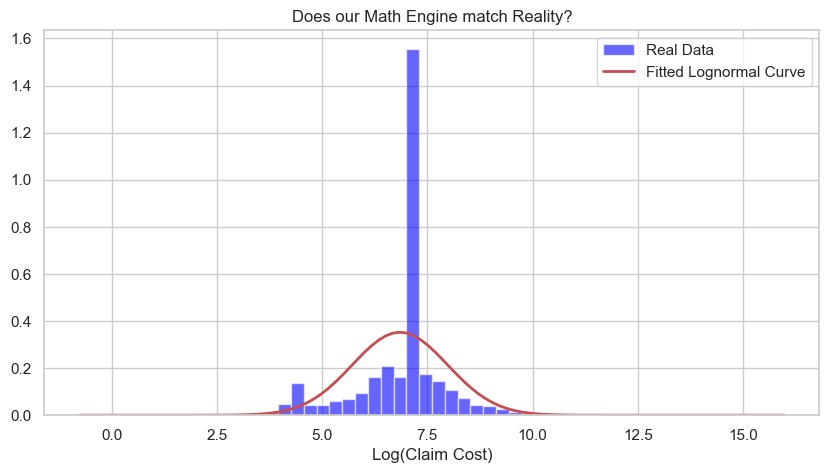

In [8]:
# ==============================================================================
# MODULE B: REINSURANCE TREATY LAB (HIGH CONTRAST MODE)
# GOAL: Simulate catastrophic accidents to price "Excess of Loss" protection.
# ==============================================================================
print("\n[MODULE B] Launching Reinsurance Stochastic Lab...")

# 1. LOAD DATA (Proxy: French Motor for Heavy-Tailed Risk)
try:
    freq_df = pd.read_csv('data/freMTPL2freq.csv')
    sev_df = pd.read_csv('data/freMTPL2sev.csv')
    sev_df = sev_df[sev_df['ClaimAmount'] > 0]
    print(f"   - Reinsurance Data Loaded: {len(sev_df)} Claims.")
except FileNotFoundError:
    print("   ! ERROR: Reinsurance CSVs not found.")

# 2. ACTUARIAL PARAMETER FITTING
# Frequency: Poisson Distribution
total_claims = freq_df['ClaimNb'].sum()
total_exposure = freq_df['Exposure'].sum()
lambda_freq = total_claims / total_exposure

# Severity: Lognormal Distribution
log_claims = np.log(sev_df['ClaimAmount'])
mu, sigma = stats.norm.fit(log_claims)

# 3. MONTE CARLO SIMULATION
# Simulate 1,000 potential years
num_simulations = 1000
num_policies = 1000

# --- FIX: LOWER RETENTION FOR VISUAL IMPACT ---
# We lower the limit to €20k so the "Green" curve moves away from the "Red" curve.
retention_limit = 20000 

gross_losses = []      # Total Loss (Unprotected)
net_losses_cedant = [] # Client Loss (Protected)

for i in range(num_simulations):
    # Step A: Frequency
    num_claims = np.random.poisson(lambda_freq * num_policies)
    
    if num_claims > 0:
        # Step B: Severity
        costs = np.random.lognormal(mu, sigma, num_claims)
        
        # Step C: Treaty Application (Excess of Loss)
        cedant_pays = np.minimum(costs, retention_limit)
        
        gross_losses.append(costs.sum())
        net_losses_cedant.append(cedant_pays.sum())
    else:
        gross_losses.append(0)
        net_losses_cedant.append(0)

results_df = pd.DataFrame({
    'Gross Loss': gross_losses, 
    'Net Loss (Client)': net_losses_cedant
})
print("   - Monte Carlo Simulation Complete.")

plt.figure(figsize=(10, 5))

# Plot the real data (Blue Histogram)
plt.hist(log_claims, bins=50, density=True, alpha=0.6, color='blue', label='Real Data')

# Plot our Math Engine (Red Line)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, sigma)
plt.plot(x, p, 'r', linewidth=2, label='Fitted Lognormal Curve')

plt.title('Does our Math Engine match Reality?')
plt.xlabel('Log(Claim Cost)')
plt.legend()
plt.show()


[MODULE C] Generating Strategic Dashboard...

>>> SUCCESS: Project Complete.
>>> OUTPUT: Dashboard saved as 'Strategic_Insurance_Dashboard_HighContrast.png'


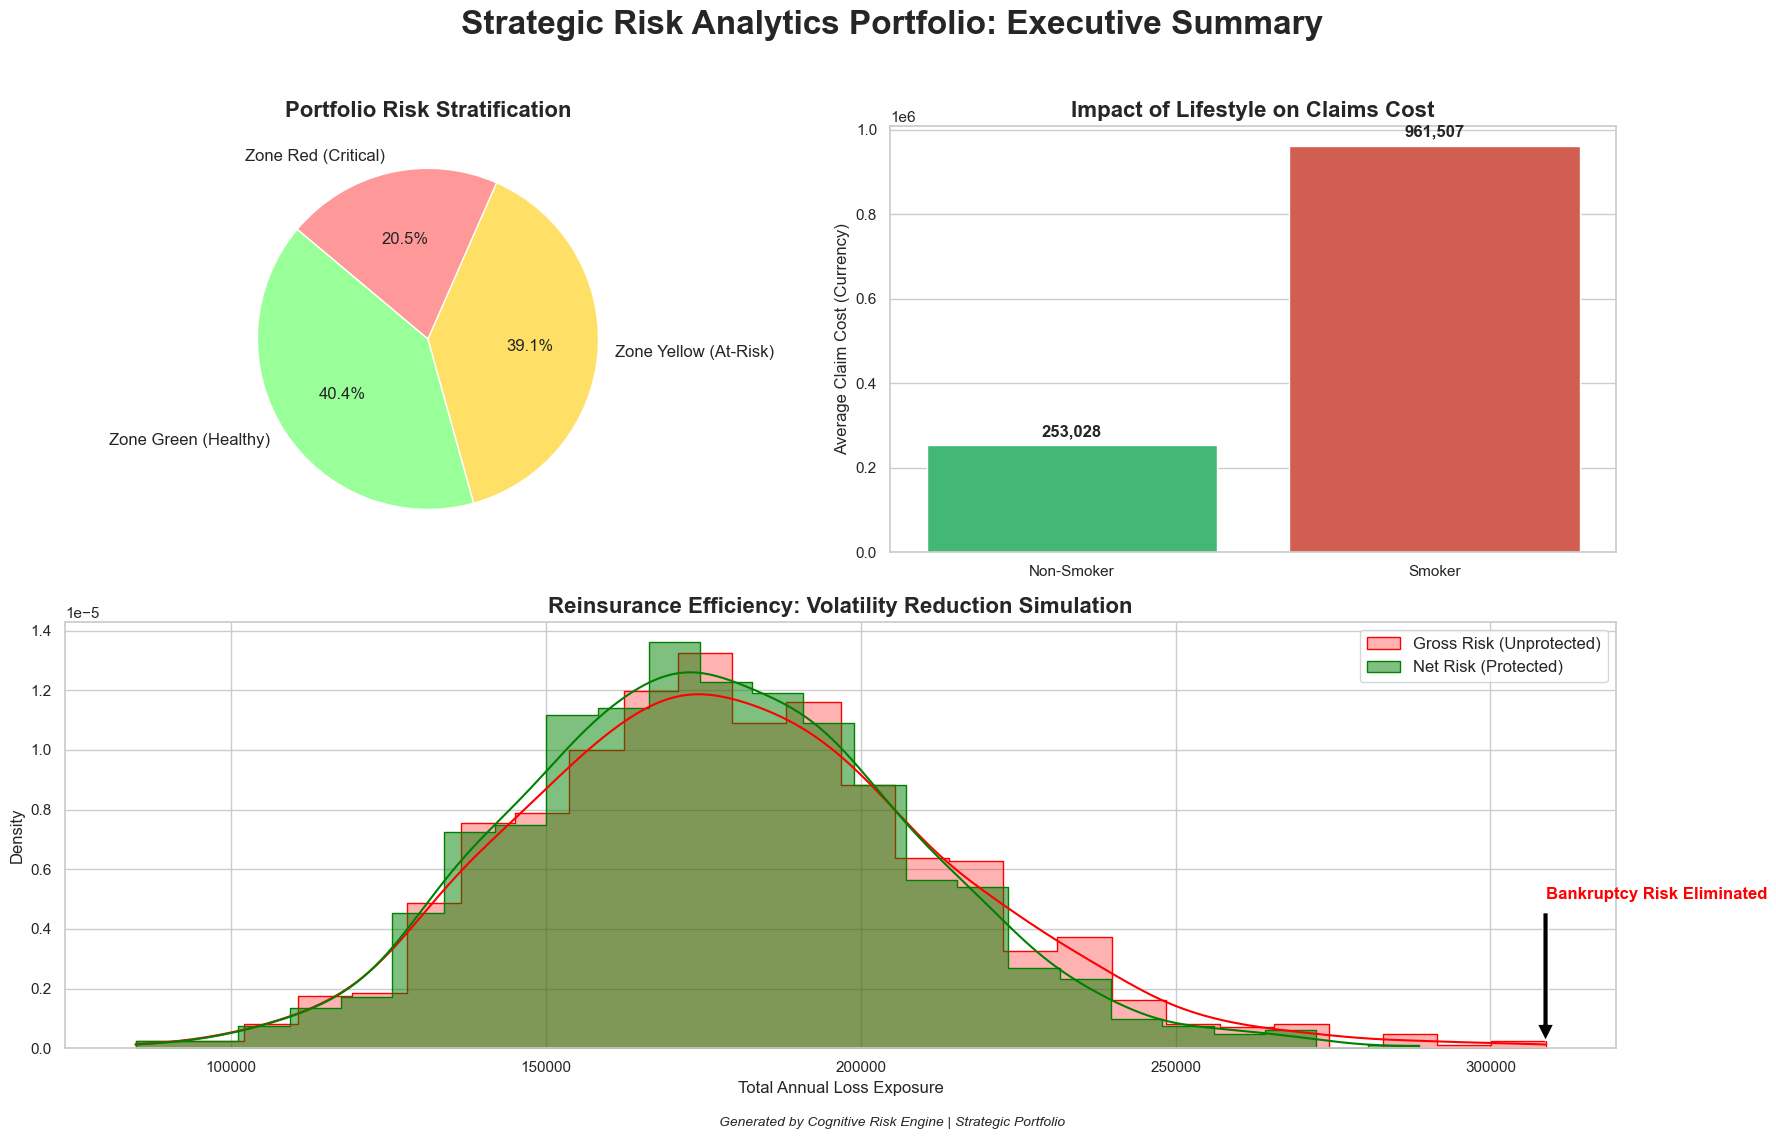

In [9]:
# ==============================================================================
# MODULE C: THE EXECUTIVE DASHBOARD (ZOOMED IN TAIL)
# GOAL: Visualize insights for C-Suite stakeholders.
# ==============================================================================
print("\n[MODULE C] Generating Strategic Dashboard...")

sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 12))
plt.suptitle('Strategic Risk Analytics Portfolio: Executive Summary', 
             fontsize=24, weight='bold', y=0.95)

# --- PANEL 1: RISK PIE CHART ---
ax1 = plt.subplot(2, 2, 1)
risk_counts = health_df['Risk_Category'].value_counts()
colors = {'Zone Red (Critical)': '#ff9999', 'Zone Yellow (At-Risk)': '#ffe066', 'Zone Green (Healthy)': '#99ff99'}

ax1.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', 
        colors=[colors[k] for k in risk_counts.index],
        startangle=140, textprops={'fontsize': 12})
ax1.set_title("Portfolio Risk Stratification", fontsize=16, weight='bold')

# --- PANEL 2: SMOKER COST IMPACT ---
ax2 = plt.subplot(2, 2, 2)
smoker_cost = health_df.groupby('smoker_code')['charges_local'].mean().reset_index()
smoker_cost['Status'] = smoker_cost['smoker_code'].map({1: 'Smoker', 0: 'Non-Smoker'})

sns.barplot(x='Status', y='charges_local', hue='Status', data=smoker_cost, 
            palette=['#2ecc71', '#e74c3c'], legend=False, ax=ax2)
ax2.set_title("Impact of Lifestyle on Claims Cost", fontsize=16, weight='bold')
ax2.set_ylabel("Average Claim Cost (Currency)", fontsize=12)
ax2.set_xlabel("")

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():,.0f}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10), 
                 textcoords='offset points', fontsize=12, weight='bold')

# --- PANEL 3: REINSURANCE EFFICIENCY (WITH TAIL HIGHLIGHT) ---
ax3 = plt.subplot(2, 1, 2)

# Use 'step' element to make the edges sharper and easier to compare
sns.histplot(results_df['Gross Loss'], color="red", label="Gross Risk (Unprotected)", 
             kde=True, stat="density", element="step", fill=True, alpha=0.3, ax=ax3)
sns.histplot(results_df['Net Loss (Client)'], color="green", label="Net Risk (Protected)", 
             kde=True, stat="density", element="step", fill=True, alpha=0.5, ax=ax3)

# Add an Annotation Arrow to point out the missing tail
max_gross = results_df['Gross Loss'].max()
max_net = results_df['Net Loss (Client)'].max()

ax3.annotate('Bankruptcy Risk Eliminated', 
             xy=(max_gross, 0), xytext=(max_gross, 0.000005),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, weight='bold', color='red')

ax3.set_title("Reinsurance Efficiency: Volatility Reduction Simulation", fontsize=16, weight='bold')
ax3.set_xlabel("Total Annual Loss Exposure", fontsize=12)
ax3.legend(fontsize=12)

# Footer & Save
plt.figtext(0.5, 0.02, "Generated by Cognitive Risk Engine | Strategic Portfolio", 
            ha="center", fontsize=10, style='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('Strategic_Insurance_Dashboard_HighContrast.png', dpi=300)

print("\n>>> SUCCESS: Project Complete.")
print(">>> OUTPUT: Dashboard saved as 'Strategic_Insurance_Dashboard_HighContrast.png'")
plt.show()